# Step 17: BTC-Only Regime Classifier (The Anchor Case)

## 🎯 Objective:
Melakukan "Sanity Check" dengan membangun model klasifikasi rezim yang **hanya menggunakan data BTC-USD**. 
Tujuannya adalah untuk melihat:
1. Seberapa akurat prediksi jika kita mengabaikan aset lain?
2. Apakah fitur multi-aset (PCA) atau topologi (Graph) benar-benar memberikan nilai tambah dibanding hanya melihat BTC?

## 📊 Features (BTC-Only):
- `BTC_Vol_20`: Volatilitas 20 hari BTC.
- `BTC_Mom_20`: Momentum 20 hari BTC.
- `BTC_Mom_50`: Momentum 50 hari BTC.

## 🎓 Task:
- **Target**: Prediksi apakah BTC besok naik > 0.5% (Bullish = 1) atau tidak (Bearish = 0).
- **Train**: 2023-2024
- **Test**: 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Environment Ready for BTC-Only Analysis!")

✅ Environment Ready for BTC-Only Analysis!


## 1. Data Selection (BTC-USD Focus)

In [2]:
# Load data
df = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
btc_series = df['BTC-USD']
btc_ret = btc_series.pct_change().fillna(0)

print(f"📊 BTC Data Loaded. Range: {btc_series.index[0].date()} to {btc_series.index[-1].date()}")

📊 BTC Data Loaded. Range: 2023-04-17 to 2025-12-31


## 2. Feature Engineering (BTC Specific)

In [3]:
features = pd.DataFrame(index=btc_ret.index)

# Fitur 1: BTC Volatility
features['BTC_Vol_20'] = btc_ret.rolling(20).std()

# Fitur 2: BTC Momentum (Short)
features['BTC_Mom_20'] = btc_ret.rolling(20).mean()

# Fitur 3: BTC Momentum (Long)
features['BTC_Mom_50'] = btc_ret.rolling(50).mean()

# Target: Binary (Bullish if next day return > 0.5%)
features['Target'] = np.where(btc_ret.shift(-1) > 0.005, 1, 0)

features = features.dropna()

print("✅ BTC-Only Features Created.")
print(features.tail())

✅ BTC-Only Features Created.
            BTC_Vol_20  BTC_Mom_20  BTC_Mom_50  Target
Date                                                  
2025-12-27    0.014486   -0.001360   -0.003033       0
2025-12-28    0.014463   -0.001471   -0.002814       0
2025-12-29    0.013354   -0.003000   -0.003450       1
2025-12-30    0.013887   -0.001897   -0.003397       0
2025-12-31    0.013902   -0.002684   -0.003039       0


## 3. Train/Test Split (2025 Prediction)

In [4]:
train_idx = features.index.year < 2025
test_idx = features.index.year == 2025

X_train = features.loc[train_idx].drop(columns=['Target'])
y_train = features.loc[train_idx, 'Target']

X_test = features.loc[test_idx].drop(columns=['Target'])
y_test = features.loc[test_idx, 'Target']

print(f"📚 Training Samples: {len(X_train)}")
print(f"🧪 Testing Samples: {len(X_test)}")

📚 Training Samples: 576
🧪 Testing Samples: 365


## 4. Modeling & Results


--- Random Forest Results ---
Accuracy: 54.79%
              precision    recall  f1-score   support

           0       0.64      0.66      0.65       232
           1       0.38      0.36      0.37       133

    accuracy                           0.55       365
   macro avg       0.51      0.51      0.51       365
weighted avg       0.54      0.55      0.55       365


--- Logistic Regression Results ---
Accuracy: 63.56%
              precision    recall  f1-score   support

           0       0.64      1.00      0.78       232
           1       0.00      0.00      0.00       133

    accuracy                           0.64       365
   macro avg       0.32      0.50      0.39       365
weighted avg       0.40      0.64      0.49       365



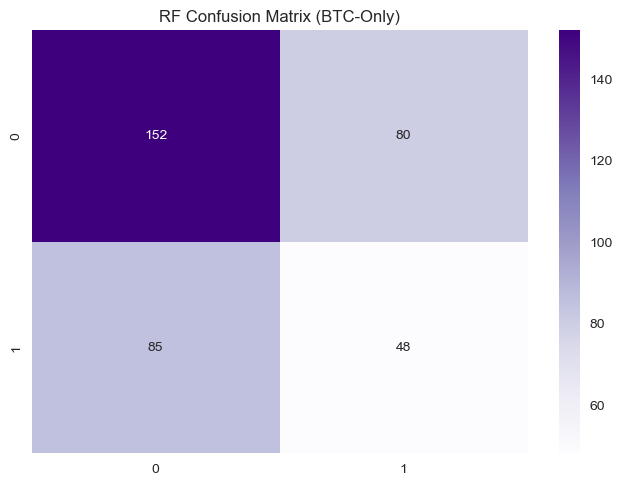

In [5]:
# Initialize Models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression()

# Fit & Predict
models = {'Random Forest': rf, 'Logistic Regression': lr}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print(classification_report(y_test, y_pred))

# Quick Visual of Confusion Matrix for RF
cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('RF Confusion Matrix (BTC-Only)')
plt.show()